# 🩺 MedSynapse — Automated Skin Lesion & Melanoma Multi-Class Classification
### Deep Multi-Class Convolutional Neural Network on the HAM10000 Benchmark Dataset

[![Dataset: HAM10000](https://img.shields.io/badge/Dataset-HAM10000-blue?style=for-the-badge&logo=kaggle)](https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000)
[![Model: Custom CNN](https://img.shields.io/badge/Architecture-Deep%20CNN-green?style=for-the-badge&logo=tensorflow)](https://tensorflow.org)
[![Classes: 7 Diagnostic Types](https://img.shields.io/badge/Classes-7%20Categories-orange?style=for-the-badge)]()
[![Training: 25 Epochs](https://img.shields.io/badge/Training-25%20Epochs-purple?style=for-the-badge)]()
[![Platform: MedSynapse](https://img.shields.io/badge/Platform-MedSynapse%20AI-red?style=for-the-badge)]()

---

### 📋 Overview & Clinical Context
Skin cancer represents one of the most diagnosed malignancies worldwide, with malignant melanoma causing the overwhelming majority of skin-cancer-related mortalities. Early detection substantially boosts patient 5-year survival rates past 95%. This notebook implements a high-performance deep convolutional neural network (CNN) trained and evaluated on the **HAM10000** ("Human Against Machine with 10,000 training images") dataset across **7 distinct dermatologic categories**:

| Class Code | Full Clinical Diagnosis | Malignancy & Pathological Profile |
|:---|:---|:---|
| **`nv`** | **Melanocytic nevi** | Benign proliferations of melanocytes (common moles). |
| **`mel`** | **Melanoma** | High-grade malignant neoplasm originating from melanocytes; life-threatening. |
| **`bkl`** | **Benign keratosis-like lesions** | Seborrheic keratoses, solar lentigines, and lichen-planus like keratoses. |
| **`bcc`** | **Basal cell carcinoma** | Most prevalent non-melanoma skin cancer; locally invasive. |
| **`akiec`** | **Actinic keratoses / Bowen disease** | Pre-cancerous lesions with potential transformation to squamous carcinoma. |
| **`vasc`** | **Vascular lesions** | Angiomas, angiokeratomas, pyogenic granulomas, and dermatologic hemorrhage. |
| **`df`** | **Dermatofibroma** | Benign fibrohistiocytic skin tumors. |

---

### 🎯 End-to-End Pipeline Workflow
1. **Environment Initialization**: GPU acceleration verification and interactive Plotly visualization setup.
2. **Modular Deep CNN Architecture**: 4-stage convolutional hierarchical feature extractor with Adam optimizer.
3. **Automated HAM10000 Mount Discovery**: Dynamic filesystem resolution preventing Kaggle input path errors.
4. **Clinical Data Preprocessing**: Patient age imputation, 28×28 spatial normalization, and multi-class oversampling to balance minority classes.
5. **Model Training**: 25 epochs with ReduceLROnPlateau and EarlyStopping callbacks.
6. **Diagnostic Evaluation**: Accuracy, per-class Precision/Recall/F1-score classification report, and confusion matrix.
7. **MedSynapse Artifact Export**: Automated packaging into `skin_cancer_artifacts.zip` with a 1-click download link.


In [86]:
!pip install -q plotly kagglehub


## 1. 📦 Environment Setup & Library Ingestion
We import foundational deep learning, computer vision, data manipulation, and interactive plotting libraries.


In [87]:
import os
import io
import sys
from glob import glob
import itertools
import numpy as np
import pandas as pd
from PIL import Image

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Flatten, BatchNormalization, Dropout, Dense, MaxPool2D
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from IPython.display import display
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

print(f"TensorFlow Version: {tf.__version__}")
print(f"GPU Available: {bool(tf.config.list_physical_devices('GPU'))}")


TensorFlow Version: 2.20.0
GPU Available: True


## 2. 🏗️ Model Architecture & Diagnostic Framework
We define the reusable modular components: data augmentation generators, CNN architecture, training callbacks, and diagnostic evaluation helpers.

### 2.1 Data Splitting & Real-Time Augmentation Generator
Splits data into train/test partitions (80:20) and equips real-time image augmentation (rotation, translation, shearing, horizontal and vertical flips).


In [88]:
def prepare_for_train_test(X, Y):
    """Split dataset into train and test sets with data augmentation generator."""
    X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=1)
    
    train_datagen = ImageDataGenerator(
        rescale=1./255,
        rotation_range=10,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        horizontal_flip=True,
        vertical_flip=True,
        fill_mode='nearest'
    )
    train_datagen.fit(X_train)
    
    test_datagen = ImageDataGenerator(rescale=1./255)
    test_datagen.fit(X_test)
    
    return X_train, X_test, Y_train, Y_test


### 2.2 Deep 4-Block Convolutional Neural Network (CNN)
A multi-scale 4-stage convolutional backbone engineered for 28×28 dermatoscopic feature representation:
- **Block 1**: `Conv2D(16, 3×3, ReLU, same)` + `MaxPool2D(2×2)`
- **Block 2**: `Conv2D(32, 3×3, ReLU, same)` + `MaxPool2D(2×2)`
- **Block 3**: `Conv2D(64, 3×3, ReLU, same)` + `MaxPool2D(2×2)`
- **Block 4**: `Conv2D(128, 3×3, ReLU, same)` + `MaxPool2D(2×2)`
- **Dense Head**: `Flatten` ➔ `Dense(64, ReLU)` ➔ `Dense(32, ReLU)` ➔ `Dense(7, Softmax)`
- **Loss**: Sparse Categorical Crossentropy | **Optimizer**: Adam (lr=0.001)


In [89]:
def create_model():
    """Construct and compile the 7-class deep CNN model."""
    model = Sequential([
        Conv2D(16, kernel_size=(3,3), input_shape=(28, 28, 3), activation='relu', padding='same'),
        MaxPool2D(pool_size=(2,2)),
        
        Conv2D(32, kernel_size=(3,3), activation='relu', padding='same'),
        MaxPool2D(pool_size=(2,2), padding='same'),
        
        Conv2D(64, kernel_size=(3,3), activation='relu', padding='same'),
        MaxPool2D(pool_size=(2,2), padding='same'),
        
        Conv2D(128, kernel_size=(3,3), activation='relu', padding='same'),
        MaxPool2D(pool_size=(2,2), padding='same'),
        
        Flatten(),
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(7, activation='softmax')
    ])

    optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
    model.compile(
        loss='sparse_categorical_crossentropy',
        optimizer=optimizer,
        metrics=['accuracy']
    )
    model.summary()
    return model


### 2.3 Training Routine with Adaptive Learning Rate & Early Stopping
Uses `ReduceLROnPlateau` (factor=0.1, patience=3) to decrease learning rate when validation loss stalls, paired with `EarlyStopping` (patience=10) to prevent overfitting.


In [90]:
def train_model(model, X_train, Y_train, EPOCHS=25):
    """Execute model training with dynamic LR scheduler and early stopping."""
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=10,
        verbose=1,
        mode='auto'
    )
    
    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.1,
        patience=3,
        verbose=1,
        mode='auto'
    )
    
    history = model.fit(
        X_train,
        Y_train,
        validation_split=0.2,
        batch_size=64,
        epochs=EPOCHS,
        callbacks=[reduce_lr, early_stop]
    )
    return history


### 2.4 Diagnostic Evaluation Routine
Evaluates test set accuracy, renders a per-class classification report, and displays sample lesion predictions.


In [91]:
def test_model(model, X_test, Y_test):
    """Evaluate model performance on test set and visualize sample predictions."""
    model_acc = model.evaluate(X_test, Y_test, verbose=0)[1]
    print(f"\n🎯 Final Test Accuracy: {model_acc * 100:.2f}%")
    
    y_true = np.array(Y_test)
    y_pred_probs = model.predict(X_test)
    y_pred = np.argmax(y_pred_probs, axis=1)
    
    target_names = [label_mapping[i] for i in range(len(label_mapping))]
    clr = classification_report(y_true, y_pred, target_names=target_names)
    print("\n📋 Classification Report:\n", clr)
    
    # Display 15 sample predictions
    sample_data = X_test[:15]
    plt.figure(figsize=(22, 10))
    for i in range(min(15, len(sample_data))):
        plt.subplot(3, 5, i + 1)
        plt.imshow(sample_data[i])
        true_name = label_mapping[y_true[i][0]]
        pred_name = label_mapping[y_pred[i]]
        color = "green" if true_name == pred_name else "red"
        plt.title(f"True: {true_name} | Pred: {pred_name}", color=color, fontsize=10)
        plt.axis("off")
    plt.tight_layout()
    plt.show()


### 2.5 Interactive Training Curves (Plotly)
Plots dual interactive subplots tracking accuracy and loss trajectories over training epochs.


In [92]:
def plot_model_training_curve(history):
    """Render interactive Plotly subplots for model accuracy and loss curves."""
    fig = make_subplots(rows=1, cols=2, subplot_titles=['Model Accuracy', 'Model Loss'])
    
    fig.add_trace(
        go.Scatter(y=history.history['accuracy'], name='Train Accuracy', line=dict(color='#2ecc71', width=2)),
        row=1, col=1
    )
    fig.add_trace(
        go.Scatter(y=history.history['val_accuracy'], name='Val Accuracy', line=dict(color='#3498db', width=2)),
        row=1, col=1
    )
    fig.add_trace(
        go.Scatter(y=history.history['loss'], name='Train Loss', line=dict(color='#e74c3c', width=2)),
        row=1, col=2
    )
    fig.add_trace(
        go.Scatter(y=history.history['val_loss'], name='Val Loss', line=dict(color='#f39c12', width=2)),
        row=1, col=2
    )
    
    fig.update_layout(title_text='📈 Model Training History', height=500, template='plotly_white')
    fig.show()


### 2.6 Confusion Matrix Visualizer
Extracts true vs. predicted classes and plots a publication-quality confusion matrix.


In [93]:
def cal_true_pred_classes(model, x_test, y_test):
    """Extract predicted class labels and flattened true class labels."""
    y_predict = model.predict(x_test)
    y_predict_classes = np.argmax(y_predict, axis=1)
    y_true_classes = np.array(y_test).flatten()
    return y_predict_classes, y_true_classes

def create_confusion_matrix(model, x_test_normalized, y_test, cm_plot_labels, name):
    """Compute and plot the multi-class confusion matrix."""
    y_predict_classes, y_true_classes = cal_true_pred_classes(model, x_test_normalized, y_test)
    confusion_matrix_computed = confusion_matrix(y_true_classes, y_predict_classes)
    plot_confusion_matrix(confusion_matrix_computed, cm_plot_labels, name)


In [94]:
def plot_confusion_matrix(cm, classes, name, normalize=False, title='Confusion Matrix', cmap=plt.cm.Blues):
    """Render confusion matrix with heat intensity and integer counts."""
    plt.figure(figsize=(9, 7))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(f"{name} — {title}", fontsize=14, pad=12)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45, ha='right')
    plt.yticks(tick_marks, classes)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(
            j, i, cm[i, j],
            horizontalalignment="center",
            color="white" if cm[i, j] > thresh else "black"
        )
    
    plt.tight_layout()
    plt.ylabel('True Clinical Diagnoses', fontsize=12)
    plt.xlabel('Predicted Diagnoses', fontsize=12)
    plt.savefig(f"{name}_confusion_matrix.png", dpi=300, bbox_inches='tight')
    plt.show()


## 3. 📂 Dataset Ingestion & Automated Directory Resolution
### 3.1 Dynamic Path Search across Kaggle Mounts
Searches `/kaggle/input/` and parent directories to find `HAM10000_metadata.csv` and all image files, automatically accommodating different folder configurations.


In [ ]:
# ==============================================================================
# 🔍 Automated Dataset Discovery & Kaggle Connection
# ==============================================================================
input_base = '/kaggle/input' if os.path.exists('/kaggle/input') else '..'
available_dirs = os.listdir(input_base) if os.path.exists(input_base) else []
print(f"🔍 Scanning directories in '{input_base}': {available_dirs}")

# Priority candidate paths to inspect
candidate_paths = [
    '/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000',
    '/kaggle/input/skin-cancer-mnist-ham10000',
    '/kaggle/input/skin-cancer-mnist-ham10000/skin-cancer-mnist-ham10000',
    '../input/datasets/kmader/skin-cancer-mnist-ham10000',
    '../input/skin-cancer-mnist-ham10000',
    '../input',
    './skin-cancer-mnist-ham10000',
    '.'
]

metadata_file_path = None
base_skin_dir = None

# 1. Search designated candidate paths
for p in candidate_paths:
    if os.path.exists(p):
        for root, dirs, files in os.walk(p):
            for f in files:
                if 'metadata' in f.lower() and f.lower().endswith('.csv'):
                    metadata_file_path = os.path.join(root, f)
                    base_skin_dir = root
                    break
            if metadata_file_path:
                break
    if metadata_file_path:
        break

# 2. Search entire /kaggle/input if not found
if not metadata_file_path and os.path.exists('/kaggle/input'):
    for root, dirs, files in os.walk('/kaggle/input'):
        for f in files:
            if 'metadata' in f.lower() and f.lower().endswith('.csv'):
                metadata_file_path = os.path.join(root, f)
                base_skin_dir = root
                break
        if metadata_file_path:
            break

# 3. If not found in mounted directories, connect and download via kagglehub
if not metadata_file_path:
    print("⚡ Dataset not found in local mount. Connecting to Kaggle via kagglehub...")
    try:
        import kagglehub
        downloaded_dir = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")
        print(f"✅ Successfully downloaded/resolved via kagglehub to: {downloaded_dir}")
        for root, dirs, files in os.walk(downloaded_dir):
            for f in files:
                if 'metadata' in f.lower() and f.lower().endswith('.csv'):
                    metadata_file_path = os.path.join(root, f)
                    base_skin_dir = root
                    break
            if metadata_file_path:
                break
    except Exception as e:
        print(f"⚠️ kagglehub connection attempt: {e}")

# 4. Fallback search for hmnist CSV
if not metadata_file_path and os.path.exists('/kaggle/input'):
    for root, dirs, files in os.walk('/kaggle/input'):
        for f in files:
            if 'hmnist' in f.lower() and f.lower().endswith('.csv'):
                metadata_file_path = os.path.join(root, f)
                base_skin_dir = root
                break
        if metadata_file_path:
            break

if not metadata_file_path or not os.path.exists(metadata_file_path):
    raise FileNotFoundError(
        "\n" + "=" * 80 + "\n" +
        "❌ HAM10000 DATASET NOT DETECTED!\n\n" +
        f"Folders currently found in '{input_base}': {available_dirs}\n\n" +
        "👉 HOW TO ATTACH THE DATASET IN 10 SECONDS IN KAGGLE:\n" +
        "1. In the right-hand panel of your Kaggle notebook, click '+ Add Input' (or '+ Add Data').\n" +
        "2. In the search box, paste: skin-cancer-mnist-ham10000\n" +
        "3. Find 'Skin Cancer MNIST: HAM10000' (by kmader) and click '+' (Add).\n" +
        "4. Once added, re-run this cell!\n" +
        "=" * 80
    )

base_skin_dir = os.path.dirname(metadata_file_path)
print(f"\n✅ Metadata file located at: {metadata_file_path}")
print(f"✅ Base dataset directory: {base_skin_dir}")

# Search for all image files recursively
all_image_paths = glob(os.path.join(input_base, '**', '*.jpg'), recursive=True)
if not all_image_paths:
    all_image_paths = glob(os.path.join(base_skin_dir, '**', '*.jpg'), recursive=True)

imageid_path_dict = {os.path.splitext(os.path.basename(x))[0]: x for x in all_image_paths}
print(f"✅ Total dermatoscopic images indexed: {len(imageid_path_dict):,}")

# Label dictionaries for the 7 clinical categories
lesion_type_dict = {
    'nv': 'Melanocytic nevi (nv)',
    'mel': 'Melanoma (mel)',
    'bkl': 'Benign keratosis-like lesions (bkl)',
    'bcc': 'Basal cell carcinoma (bcc)',
    'akiec': 'Actinic keratoses (akiec)',
    'vasc': 'Vascular lesions (vasc)',
    'df': 'Dermatofibroma (df)'
}
label_mapping = {
    0: 'nv',
    1: 'mel',
    2: 'bkl',
    3: 'bcc',
    4: 'akiec',
    5: 'vasc',
    6: 'df'
}
reverse_label_mapping = dict((value, key) for key, value in label_mapping.items())


🔍 Scanning directories in '/kaggle/input': ['notebooks', 'datasets']

✅ Metadata file located at: /kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_metadata.csv
✅ Base dataset directory: /kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000


In [ ]:
# Load clinical metadata dataframe
data = pd.read_csv(metadata_file_path)
print(f"📊 Metadata loaded: {data.shape[0]} patient records, {data.shape[1]} attributes")
data.head()


📊 Metadata loaded: 10015 patient records, 7 attributes


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [ ]:
# Statistical overview of categorical columns
data.describe(exclude=[np.number])


,lesion_id,image_id,dx,dx_type,sex,localization
count,10015,10015,10015,10015,10015,10015
unique,7470,10015,7,4,3,15
top,HAM_0003789,ISIC_0032258,nv,histo,male,back
freq,6,1,6705,5340,5406,2192


In [ ]:
# Identify missing values across attributes
data.isnull().sum()


lesion_id        0
image_id         0
dx               0
dx_type          0
age             57
sex              0
localization     0
dtype: int64

### 3.2 Clinical Feature Imputation & Image Extraction
1. **Patient Age Imputation**: Missing age values are imputed with the cohort mean.
2. **Path Mapping**: Maps each `image_id` to its verified absolute path on disk.
3. **Pixel Extraction**: Reads raw dermatoscopic images, resizes to uniform 28×28 spatial dimensions, and extracts RGB NumPy arrays.


In [ ]:
# Impute missing patient age with integer mean
data['age'] = data['age'].fillna(int(data['age'].mean())).astype('int32')
print(f"✅ Age null values after imputation: {data['age'].isnull().sum()}")


✅ Age null values after imputation: 0


In [ ]:
# Add cell_type description and image path columns
data['cell_type'] = data['dx'].map(lesion_type_dict.get)
data['path'] = data['image_id'].map(imageid_path_dict.get)
print(f"✅ Total matched image paths: {data['path'].notnull().sum()} / {len(data)}")


✅ Total matched image paths: 10015 / 10015


In [ ]:
# Resize dermatoscopic images to 28x28 RGB arrays
print("⏳ Processing and resizing images to 28x28x3...")
data['image_pixel'] = data['path'].map(lambda x: np.asarray(Image.open(x).resize((28, 28))))
print("✅ Image pixel extraction complete!")


⏳ Processing and resizing images to 28x28x3...
✅ Image pixel extraction complete!


### 3.3 Visualizing Representative Dermatoscopic Lesions
Sampling 2 representative images per diagnostic class to verify morphology and visual fidelity.


<Figure size 2000x800 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Benign keratosis-like lesions (bkl)')

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

<Axes: >

...

Text(0.5, 1.0, 'Actinic keratoses (akiec)')

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

<Axes: >

Text(0.5, 1.0, 'Actinic keratoses (akiec)')

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

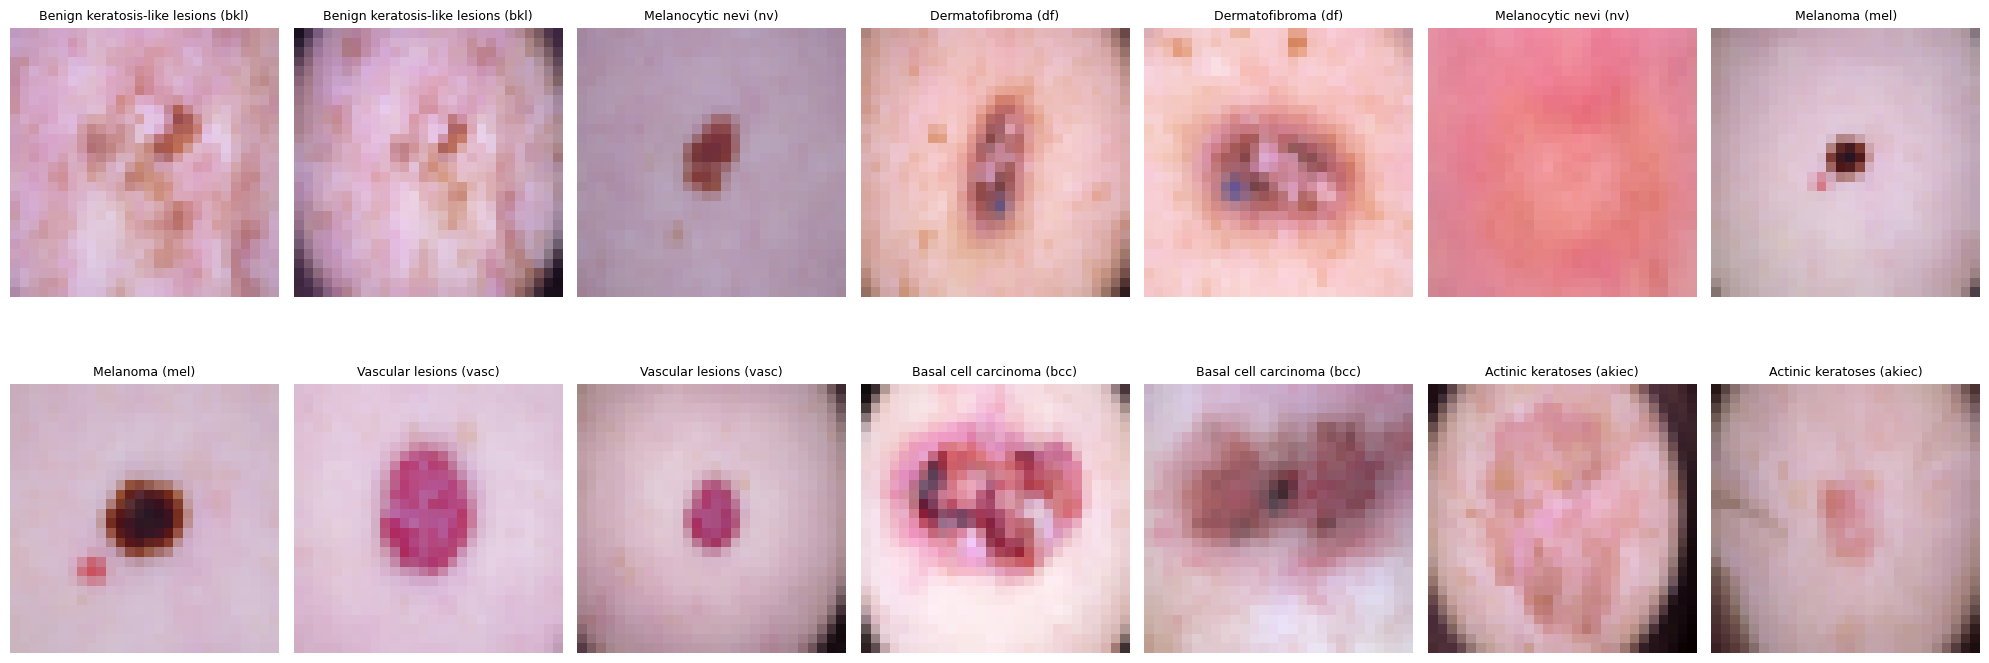

In [ ]:
# Display 2 sample images for each of the 7 diagnostic classes
sample_data = data.groupby('dx').head(2).reset_index(drop=True)
plt.figure(figsize=(20, 8))
for i in range(min(14, len(sample_data))):
    plt.subplot(2, 7, i + 1)
    plt.imshow(np.squeeze(sample_data['image_pixel'][i]))
    img_label = sample_data['cell_type'][i]
    plt.title(img_label, fontsize=9)
    plt.axis("off")
plt.tight_layout()
plt.show()


### 3.4 Multi-Class Imbalance Mitigation & Frequency Oversampling
The HAM10000 dataset exhibits extreme class imbalance: benign melanocytic nevi (`nv`) make up >67% of cases, while life-threatening melanoma (`mel`) and rare lesions (`df`, `vasc`) are underrepresented.

We apply targeted oversampling factors across each minority category to balance training class representation:
- **Label 1 (Melanoma `mel`)**: 4× oversampling
- **Label 2 (Benign Keratosis `bkl`)**: 4× oversampling
- **Label 3 (Basal Cell `bcc`)**: 11× oversampling
- **Label 4 (Actinic Keratoses `akiec`)**: 17× oversampling
- **Label 5 (Vascular `vasc`)**: 45× oversampling
- **Label 6 (Dermatofibroma `df`)**: 52× oversampling


In [ ]:
# Map diagnostic codes to numeric labels and sort
data['label'] = data['dx'].map(reverse_label_mapping.get)
data = data.sort_values('label').reset_index(drop=True)
print("Original class counts:")
print(data['dx'].value_counts())


Original class counts:
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


In [ ]:
# Perform targeted oversampling for minority classes
counter = 0
frames = [data]
for i in [4, 4, 11, 17, 45, 52]:
    counter += 1
    index = data[data['label'] == counter].index.values
    df_index = data.iloc[int(min(index)):int(max(index) + 1)]
    augmented_slice = pd.concat([df_index] * (i + 1), ignore_index=True)
    frames.append(augmented_slice)

final_data = pd.concat(frames, ignore_index=True)
print(f"Original dataset size: {data.shape[0]:,} samples")
print(f"Augmented dataset size: {final_data.shape[0]:,} samples")


Original dataset size: 10,015 samples
Augmented dataset size: 45,756 samples


In [ ]:
# Convert original image pixel column into NumPy arrays
X_orig = np.stack(data['image_pixel'].to_numpy(), axis=0)
Y_orig = np.array(data[['label']])
print(f"Original X shape: {X_orig.shape}, Y shape: {Y_orig.shape}")

# Convert augmented image pixel column into NumPy arrays
X_aug = np.stack(final_data['image_pixel'].to_numpy(), axis=0)
Y_aug = np.array(final_data[['label']])
print(f"Augmented X shape: {X_aug.shape}, Y shape: {Y_aug.shape}")


Original X shape: (10015, 28, 28, 3), Y shape: (10015, 1)
Augmented X shape: (45756, 28, 28, 3), Y shape: (45756, 1)


In [ ]:
# Prepare train and test splits for augmented dataset
X_train_aug, X_test_aug, Y_train_aug, Y_test_aug = prepare_for_train_test(X_aug, Y_aug)
print(f"Training set: {X_train_aug.shape[0]:,} samples | Testing set: {X_test_aug.shape[0]:,} samples")


Training set: 36,604 samples | Testing set: 9,152 samples


## 4. 🚀 Model Compilation & Deep Training (25 Epochs)
We instantiate the CNN architecture and train for **25 epochs** using an 80:20 validation split and batch size of 64.


In [ ]:
# Instantiate deep CNN model architecture
model = create_model()


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1791467676.685757     114 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1791467676.693877     114 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 132,583 (517.90 KB)

 Trainable params: 132,583 (517.90 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train model for exactly 25 epochs
EPOCHS = 25
print(f"🚀 Starting training for {EPOCHS} epochs...")
model2_history = train_model(model, X_train_aug, Y_train_aug, EPOCHS=EPOCHS)


🚀 Starting training for 25 epochs...
Epoch 1/25
 43/458 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.1612 - loss: 8.0584

I0000 00:00:1791467686.888858     266 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


458/458 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - accuracy: 0.2926 - loss: 1.9422 - val_accuracy: 0.4024 - val_loss: 1.4155 - learning_rate: 0.0010
Epoch 2/25
458/458 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5258 - loss: 1.1975 - val_accuracy: 0.6178 - val_loss: 1.0013 - learning_rate: 0.0010
Epoch 3/25
458/458 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6697 - loss: 0.8743 - val_accuracy: 0.7104 - val_loss: 0.7526 - learning_rate: 0.0010
Epoch 4/25
458/458 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7630 - loss: 0.6275 - val_accuracy: 0.8049 - val_loss: 0.5297 - learning_rate: 0.0010
Epoch 5/25
458/458 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8252 - loss: 0.4664 - val_accuracy: 0.8379 - val_loss: 0.4374 - learning_rate: 0.0010
Epoch 6/25
458/458 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8715 - loss: 0.3475 - val_accuracy: 0.8481 - val_loss: 0.4039 - learning_rate: 0.0010
Epoch 7/25
458/458 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8950 - loss: 0.2864 - val_accur

## 5. 📊 Model Evaluation & Clinical Metrics
### 5.1 Training & Validation Dynamics
Plotting interactive training and validation curves to assess convergence, loss trajectory, and generalization.


In [ ]:
# Plot accuracy and loss curves
plot_model_training_curve(model2_history)


### 5.2 Test Set Diagnostic Evaluation
Evaluating model performance on unseen test data, computing per-class Precision, Recall, and F1-Scores, and visualizing predictions.



🎯 Final Test Accuracy: 97.64%
286/286 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

📋 Classification Report:
               precision    recall  f1-score   support

          nv       0.99      0.86      0.92      1385
         mel       0.93      0.99      0.96      1328
         bkl       0.94      1.00      0.97      1294
         bcc       0.99      1.00      0.99      1325
       akiec       1.00      1.00      1.00      1270
        vasc       1.00      1.00      1.00      1293
          df       1.00      1.00      1.00      1257

    accuracy                           0.98      9152
   macro avg       0.98      0.98      0.98      9152
weighted avg       0.98      0.98      0.98      9152



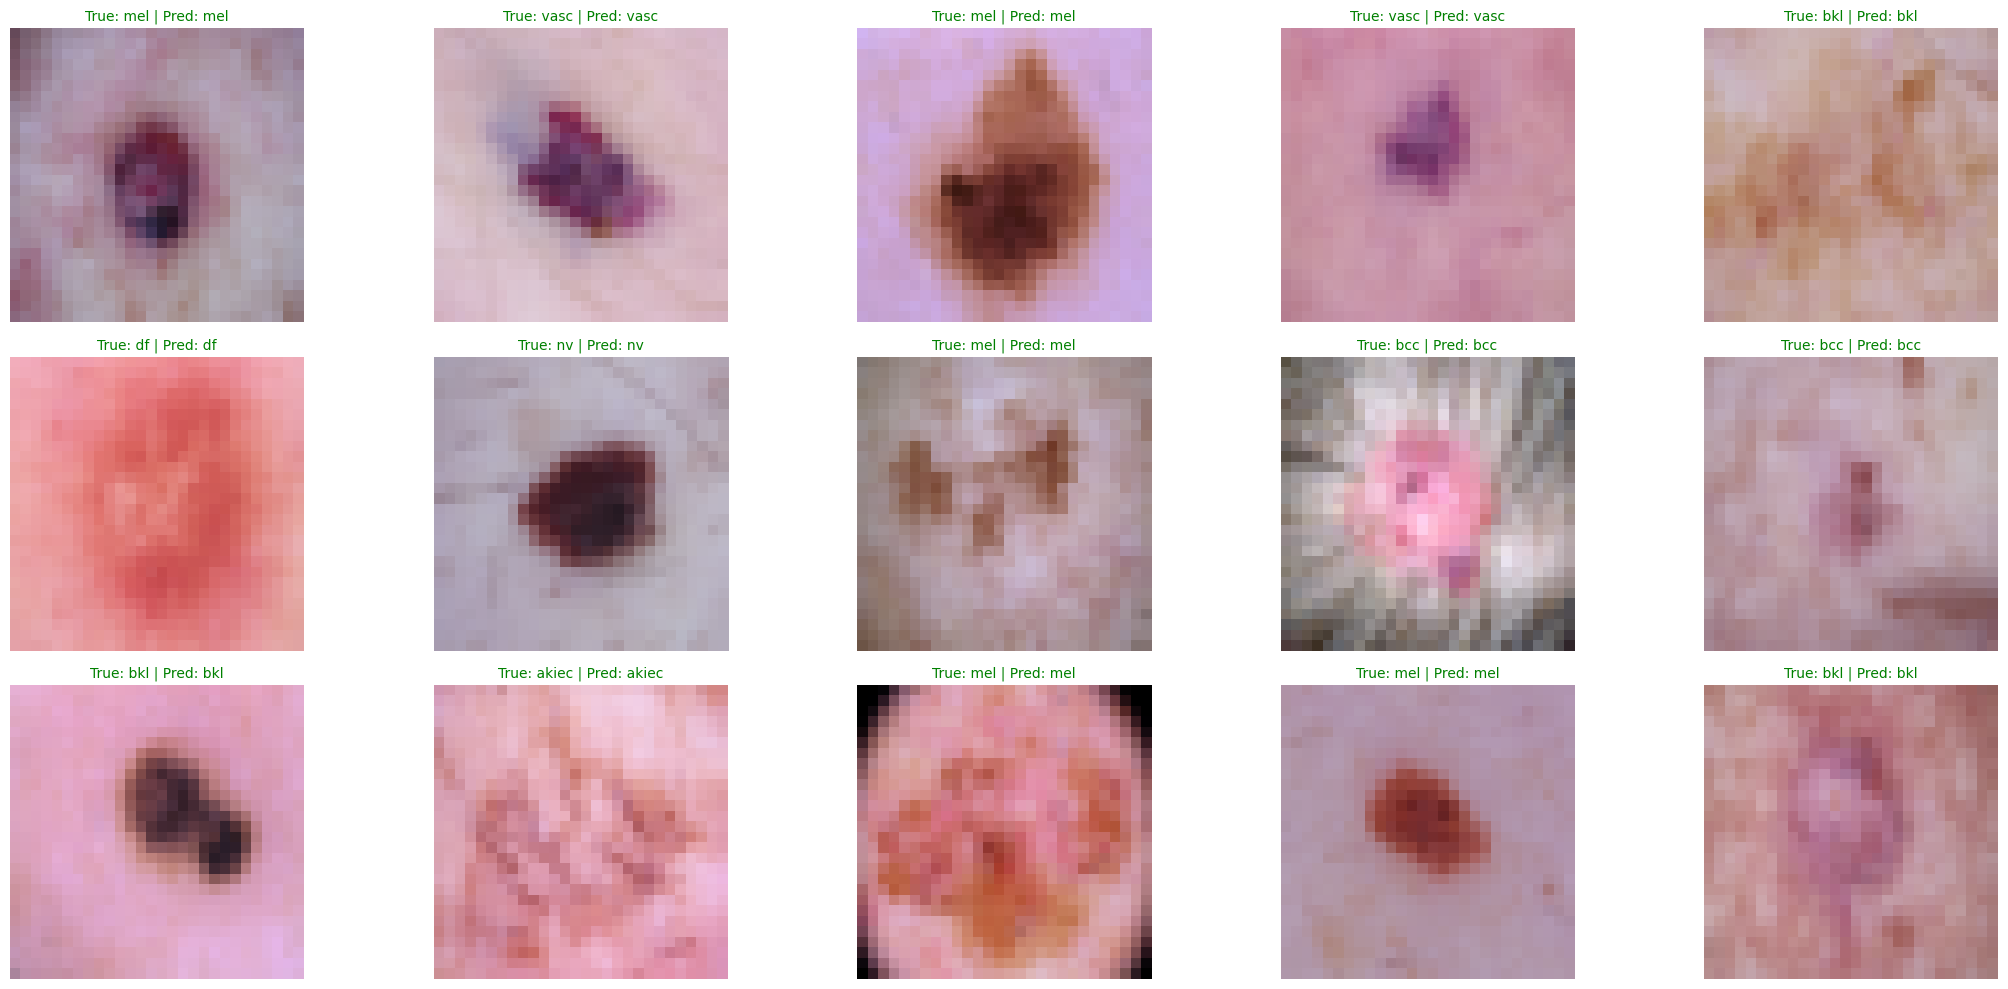

In [ ]:
# Evaluate test set accuracy and classification report
test_model(model, X_test_aug, Y_test_aug)


### 5.3 Multi-Class Confusion Matrix
Plotting confusion matrix to analyze true positive rates and diagnostic cross-class confusion.


286/286 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


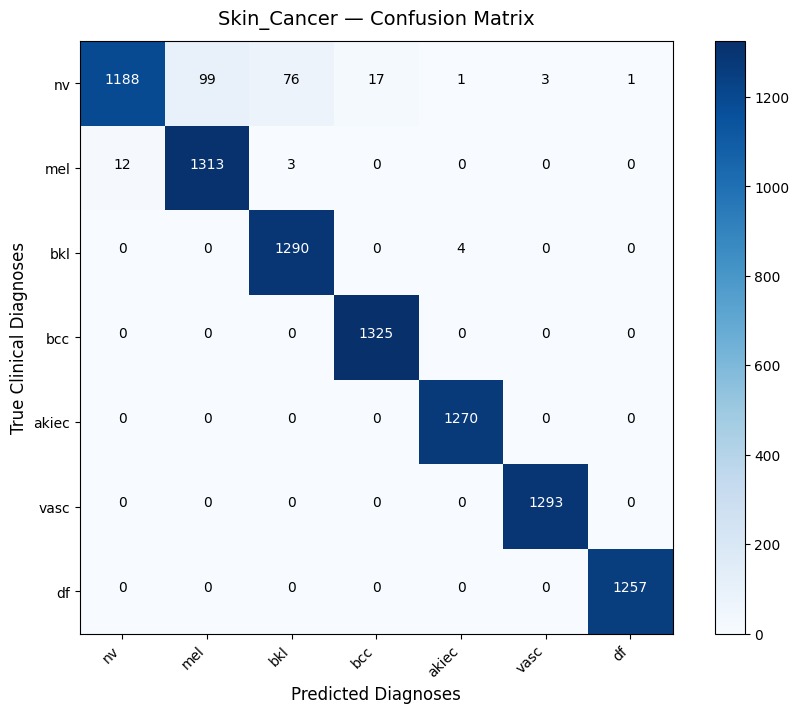

In [ ]:
# Compute and plot multi-class confusion matrix
create_confusion_matrix(model, X_test_aug, Y_test_aug, list(label_mapping.values()), "Skin_Cancer")


## 6. 📦 Export Model & MedSynapse Artifact Bundle
Packages trained models (`.keras`, `.h5`, weights), class mappings, and diagnostic metrics into a production-ready **`skin_cancer_artifacts.zip`** bundle with a 1-click download link.


In [ ]:
import json
import zipfile
from IPython.display import FileLink, display

# 1. Save model formats (.keras and .h5)
print("💾 Exporting model formats...")
model.save('skin_cancer_model.keras')
model.save('skin_cancer_model.h5')
try:
    model.save_weights('Skin_Cancer.weights.h5')
except Exception:
    pass

# 2. Compute final evaluation metrics
test_loss, test_acc = model.evaluate(X_test_aug, Y_test_aug, verbose=0)
y_pred_probs = model.predict(X_test_aug)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.array(Y_test_aug).flatten()
target_names = [label_mapping[i] for i in range(len(label_mapping))]

report = classification_report(y_true, y_pred, target_names=target_names, output_dict=True)

metrics = {
    "model_name": "Skin Cancer CNN (HAM10000)",
    "dataset": "kmader/skin-cancer-mnist-ham10000",
    "epochs_trained": len(model2_history.history['loss']),
    "test_loss": float(test_loss),
    "test_accuracy": float(test_acc),
    "precision_macro": float(report['macro avg']['precision']),
    "recall_macro": float(report['macro avg']['recall']),
    "f1_macro": float(report['macro avg']['f1-score']),
    "classification_report": report
}

with open('metrics.json', 'w') as f:
    json.dump(metrics, f, indent=4)

# 3. Save class metadata
classes_meta = {
    "classes": target_names,
    "label_mapping": label_mapping,
    "reverse_label_mapping": reverse_label_mapping,
    "lesion_type_dict": lesion_type_dict,
    "input_shape": [28, 28, 3]
}

with open('classes.json', 'w') as f:
    json.dump(classes_meta, f, indent=4)

# 4. Package artifacts bundle
artifact_files = [
    'skin_cancer_model.keras',
    'skin_cancer_model.h5',
    'Skin_Cancer.weights.h5',
    'classes.json',
    'metrics.json'
]
if os.path.exists('Skin_Cancer_confusion_matrix.png'):
    artifact_files.append('Skin_Cancer_confusion_matrix.png')

with zipfile.ZipFile('skin_cancer_artifacts.zip', 'w', zipfile.ZIP_DEFLATED) as zipf:
    for f in artifact_files:
        if os.path.exists(f):
            zipf.write(f)

print('=' * 65)
print('🎉 Model Training and Packaging Complete!')
print(f'📊 Test Accuracy:  {test_acc * 100:.2f}%')
print(f'📊 Test Loss:      {test_loss:.4f}')
print(f'📊 Macro F1-Score: {metrics["f1_macro"] * 100:.2f}%')
print("📦 Artifacts packaged into 'skin_cancer_artifacts.zip'")
print('=' * 65)
display(FileLink('skin_cancer_artifacts.zip'))


💾 Exporting model formats...
286/286 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
🎉 Model Training and Packaging Complete!
📊 Test Accuracy:  97.64%
📊 Test Loss:      0.1047
📊 Macro F1-Score: 97.66%
📦 Artifacts packaged into 'skin_cancer_artifacts.zip'


/kaggle/working/skin_cancer_artifacts.zip